In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
import control as ct

from matplotlib import pyplot as plt
from scipy.linalg import block_diag
from sklearn.model_selection import train_test_split

import kind
import utils_data
import utils_nn

In [2]:
class linear_system:
    def __init__(self, matrix):
        self.matrix = matrix

    def __call__(self, x):
        return torch.matmul(x, torch.transpose(self.matrix, 0, 1))


### Defining a reward function

In [3]:
class quadratic_fun:
    def __init__(self, matrix):
        self.matrix = matrix

    def __call__(self, x):
        return torch.einsum('btc,cd,btd->bt', x, self.matrix, x).unsqueeze(-1)

state_ndim = 1
action_ndim = 1

state_cost = 0.1 * torch.eye(state_ndim)
action_cost = 0.1 * torch.eye(action_ndim)

reward_fun = quadratic_fun(torch.block_diag(-state_cost, -action_cost))

### Discounted return function

In [4]:
class montecarlo_fun:
    def __init__(self, discount=0.95):
        self.gamma = discount

    def __call__(self, reward):
        return torch.sum(torch.stack([self.gamma**j * r for j, r in enumerate(reward)]), dim=1, keepdim=True)

gamma = 0.98
return_fun = montecarlo_fun(gamma)

In [5]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'SRF gun simulation',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.2',
        '--data_test_size', '0.8',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '24',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [6]:
dataset = utils_data.dataset_factory().create_dataset(args)
_, _, data_loader = dataset.load(data_type='mixed')

In [7]:
model = kind.model(args)

model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

model(
  (stationary): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=960, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=20, out_features=10, bias=False)
    (mod_mean): Linear(in_features=10, out_features=10, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=600, bias

given state tensor([[[ 0.4010, -0.0283]]]), value will be tensor([[[-0.4713]]])


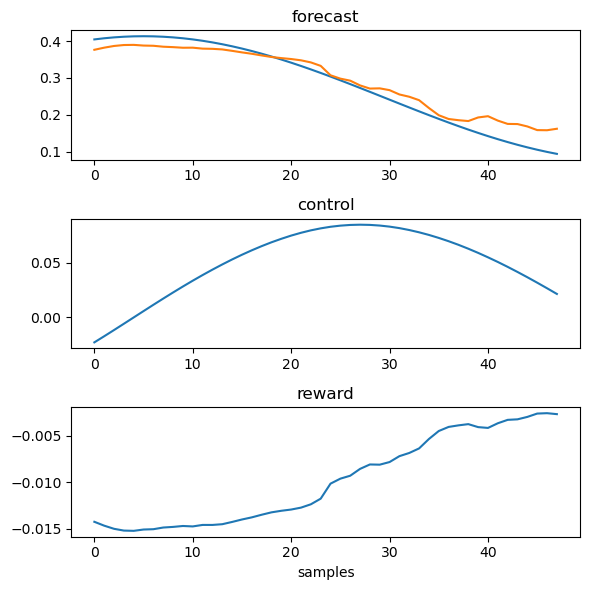

In [8]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:

        back = back[[jdata]]
        model_output = model(back)
        blend = model_output[0]

        curr_state = back[:, [-1]]
        forecast = blend[:, args.lookback_nsample:]

        u = torch.unsqueeze(fore[jdata, :, [1]], 0)
        r = reward_fun(torch.cat([forecast, u], dim=-1))
        v = return_fun(r)
        print(f'given state {curr_state}, value will be {v}')

        plt.figure(figsize=(6,6))

        plt.subplot(3,1,1)
        plt.title('forecast')
        plt.plot(fore[jdata, :, :1])
        plt.plot(forecast[0, :, :1])

        plt.subplot(3,1,2)
        plt.title('control')
        plt.plot(u[0])

        plt.subplot(3,1,3)
        plt.title('reward')
        plt.plot(r[0])

        plt.xlabel('samples')

        plt.tight_layout()
        plt.show()

        break

In [9]:
value_fun_data = []

with torch.no_grad():
    for back, fore in data_loader:
        model_output = model(back)
        blend = model_output[0]

        s = back[:, [-1]]
        forecast = blend[:, args.lookback_nsample:]
        u = fore[:, :, [1]]
        r = reward_fun(torch.cat([forecast, u], dim=-1))
        v = return_fun(r)
        value_fun_data.append(torch.cat([s, v], dim=-1))

value_fun_data = torch.cat(value_fun_data, dim=0)
print(f'value function data is shaped as {value_fun_data.shape}')

value function data is shaped as torch.Size([13333, 1, 3])


In [10]:
class feature_scaler:
    def __init__(self, x):
        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True) + 1e-8

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse(self, x_scaled):
        return x_scaled * self.std + self.mean

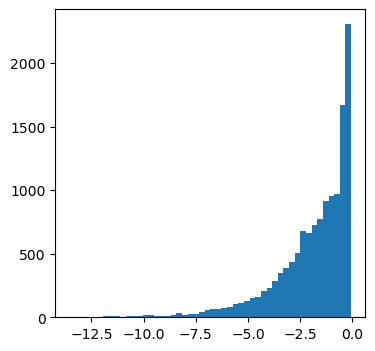

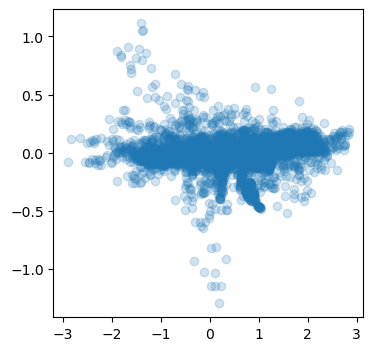

In [11]:
state, value = torch.split(value_fun_data, [2, 1], dim=-1)
detuning, control = torch.split(state, [1, 1], dim=-1)

with torch.no_grad():
    plt.figure(figsize=(4,4))
    plt.hist(value.flatten(), bins=50)
    plt.show()

    plt.figure(figsize=(4,4))
    plt.scatter(detuning.flatten(), control.flatten(), alpha=0.2)
    plt.show()

In [12]:
# --! make a train/test split
train_size = 0.8
test_size = 0.5
train_data, valid_test_data = train_test_split(value_fun_data, train_size=train_size, shuffle=True)
valid_data, test_data = train_test_split(valid_test_data, test_size=test_size, shuffle=True)

# --! split data into inputs and labels
train_state, train_value = torch.split(train_data, [2, 1], dim=-1)
valid_state, valid_value = torch.split(valid_data, [2, 1], dim=-1)
test_state, test_value = torch.split(test_data, [2, 1], dim=-1)

train_state = train_state.reshape(train_state.shape[0], -1)
train_value = train_value.reshape(train_value.shape[0], -1)
valid_state = valid_state.reshape(valid_state.shape[0], -1)
valid_value = valid_value.reshape(valid_value.shape[0], -1)
test_state = test_state.reshape(test_state.shape[0], -1)
test_value = test_value.reshape(test_value.shape[0], -1)

# --! scale train data
#train_state = train_state - train_state.mean(dim=0, keepdim=True)
#train_state = utils_data.minmax_scaler().fit_transform(train_state, dim=0)
#train_value = train_value - train_value.mean(dim=0, keepdim=True)
#train_value = utils_data.minmax_scaler().fit_transform(train_value, dim=0)

# --! assemble train/valid/test datasets
train_dataset = torch.utils.data.TensorDataset(train_state, train_value)
valid_dataset = torch.utils.data.TensorDataset(valid_state, valid_value)
test_dataset = torch.utils.data.TensorDataset(test_state, test_value)

# --! wrap datasets into data loaders
batch_size = 32
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [13]:
def validate(model, data_loader):

    total_loss = []

    # --! set this model into evaluation mode
    model.eval()

    with torch.no_grad():
        for state, value in data_loader:

            value_pred = model(state)

            criterion = torch.nn.MSELoss()
            loss = criterion(value_pred, value)
            total_loss.append(loss)

    # --! reset this model back to training mode
    model.train()

    return np.average(total_loss)

In [14]:
value_fun_ni = 2
value_fun_no = 1
value_fun = utils_nn.fcnn(feat=[value_fun_ni, 64, 64, 64, value_fun_no], actfun_hid='relu')

learning_rate = 1e-3
weight_decay = 1e-12
value_fun_optim = torch.optim.Adam(
    value_fun.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

patience = 20
checkpoints = '../../models/delay/value'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

value_fun.train()
nepoch = 300
for epoch in range(nepoch):
    train_loss = []

    for state, value in train_loader:
        value_fun_optim.zero_grad()

        value_pred = value_fun(state)
        criterion = torch.nn.MSELoss()
        loss = criterion(value_pred, value)
        train_loss.append(loss.item())

        loss.backward()
        value_fun_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate(value_fun, valid_loader)
    test_loss = validate(value_fun, test_loader)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(value_fun, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
value_fun.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=2.572160, valid=2.171686, test=2.174591
	validation loss decreased (inf -> 2.171686), saving model ...
	epoch 2 losses: train=2.187185, valid=2.073471, test=2.190536
	validation loss decreased (2.171686 -> 2.073471), saving model ...
	epoch 3 losses: train=2.132219, valid=2.054497, test=2.129236
	validation loss decreased (2.073471 -> 2.054497), saving model ...
	epoch 4 losses: train=2.084175, valid=2.075611, test=2.107138
	early stopping counter: 1 out of 20
	epoch 5 losses: train=2.070185, valid=1.994378, test=2.090214
	validation loss decreased (2.054497 -> 1.994378), saving model ...
	epoch 6 losses: train=2.058050, valid=2.077314, test=2.102063
	early stopping counter: 1 out of 20
	epoch 7 losses: train=2.044770, valid=2.006166, test=2.170305
	early stopping counter: 2 out of 20
	epoch 8 losses: train=2.035379, valid=2.179507, test=2.183159
	early stopping counter: 3 out of 20
	epoch 9 losses: train=2.028578, valid=2.032438, test=2.135005
	early stopping co

<All keys matched successfully>

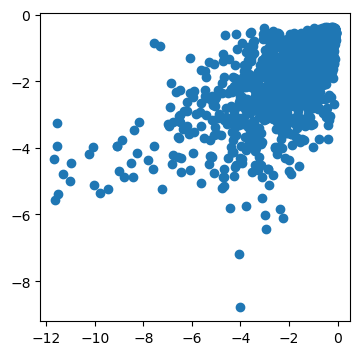

In [17]:
value_true = []
value_pred = []

value_fun.eval()
with torch.no_grad():
    for state, value in test_loader:
        model_o = value_fun(state)

        value_true.append(value)
        value_pred.append(model_o)

    value_true = torch.cat(value_true, dim=0)
    value_pred = torch.cat(value_pred, dim=0)

    plt.figure(figsize=(4,4))
    plt.scatter(value_true, value_pred)
    plt.show()